In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

In [ ]:
# Making codes
codes = []
code_types = []
code_nkds = []
code_data_coodes = []

ds_surface = [3, 5, 7, 9, 11]
for d in ds_surface:
    code = RotatedSurfaceCode(d)
    codes.append(code)
    code_types.append('Surface')
    code_nkds.append(code.compute_code_parameters())

nkds_tile = [(288,8,12), (288, 8, 14), (288, 18, 13), (512, 18, 19)]
for nkd in nkds_tile:
    code = TileCode.known_code(*nkd)
    codes.append(code)
    code_types.append('Tile')
    code_nkds.append(nkd)

rs_simplex = [3,4]
for r in rs_simplex:
    code = HGPCode.simplex_code(r)
    codes.append(code)
    code_types.append('Simplex')
    code_nkds.append(code.compute_code_parameters())

rs_cube = [3,4]
for r in rs_cube:
    code = HypercubeCode(r)
    codes.append(code)
    code_types.append('Hypercube')
    code_nkds.append(code.compute_code_parameters())

lms = [
    (6,6),
    (15,3),
    (9,6),
    (12,6),
    (12,12),
]
orders = [
    (([3], [1,2]), ([1, 2], [3])),
    (([9], [1, 2]), ([2, 7], [0])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [1, 2]), ([1, 2], [3])),
    (([3], [2, 7]), ([1, 2], [3])),
]
nkds = [
    (72, 12, 6),
    (90, 8, 10),
    (108, 8, 10),
    (144, 12, 12),
    (288, 12, 18),
]
for (l,m),(a_ord,b_ord) in zip(lms, orders):
    code = GBCode(l, m, a_ord, b_ord)
    codes.append(code)
    code_types.append('BB')

code_nkds += nkds

rsds_radial = [(3,5,10), (3,8,12), (3,11,14), (4,6,12), (4,7,14), (4,8,16), (4,11,20)]
for r,s,d in rsds_radial:
    code = RadialCode(r,s,d)
    codes.append(code)
    code_types.append('Radial')
    code_nkds.append(code.compute_code_parameters())

for code in codes:
    assert len(code.qubit_coords) > 0, code

In [35]:
compile_tasks = True
if compile_tasks:
    hwp = device.default_hwp
    ps_surface = np.geomspace(2e-3, 4e-3, 5)
    ps_other = np.geomspace(1e-3, 2e-3, 5)
    # p = 1e-3
    # t2 = 1e-3
    # p_sh = 1e-3
    # error_params = device.error_params(p=p, T2=t2, p_sh=p_sh)
    buffer = 3
    basis = 'X'
    schedules = dict()
    tasks = []
    for code, code_type, (n,k,d) in zip(codes, code_types, code_nkds):
        print(code_type, f'[[{n}, {k}, {d}]]...')
        xmax,ymax = 0,0
        data_coords = dict()
        for i in code.data_indices:
            x,y = code.qubit_coords[i]
            data_coords[i] = (x+buffer, y+buffer)
            xmax = max(xmax, x)
            ymax = max(ymax, y)
        dev = device.UnitCellDevice(xmax+2*buffer, ymax+2*buffer, hwp)
        
        rounds = d

        if code_type == 'Surface':
            sched = code.get_schedule(hwp, 'Z', rounds=rounds, refocus_shuttling_noise=True)
        else:
            sched = dev.compile_QEC_schedule(
                code,
                data_coords,
                code.check_cx_layers,
                rounds=rounds,
                use_highways=True,
                refocus_shuttle_noise=True,
                optimize_ancilla_start=True,
                separate_X_Z=code_type != 'Surface',
            )
        schedules[(code_type, (n,k,d))] = sched
        
        for p in (ps_surface if code_type == 'Surface' else ps_other):
            p = p
            T2 = 10**(-6-np.log10(p))
            p_sh = p
            error_params = device.error_params(p=p, T2=T2, p_sh=p_sh)
            circ = sched.to_stim_circuit(code, basis, error_params, XYZ_decode=False)
            try:
                circ.detector_error_model()
            except Exception as e:
                print('FAIL', e)

            decoder='pymatching' if code_type == 'Surface' else 'bposd'
            tasks.append(sinter.Task(
                circuit=circ,
                decoder=decoder,
                json_metadata={'n':n, 'k':k, 'd':d, 'type':code_type, 'rounds':rounds, 'basis':basis, 'decoder':decoder, 'p':p, 'T2':T2, 'p_sh':p_sh},
            ))
    with open('notebooks/data/10_tasks.pkl', 'wb') as f:
        pickle.dump({
            'tasks':tasks,
        }, f)
    with open('notebooks/data/10_params.pkl', 'wb') as f:
        pickle.dump({
            'code_types':code_types,
            'code_nkds':code_nkds,
            'code_data_coodes':code_data_coodes,
            'ps_surface': ps_surface,
            'ps_other': ps_other,
            'schedules':schedules,
        }, f)
else:
    try:
        with open('notebooks/data/10_tasks.pkl', 'rb') as f:
            data = pickle.load(f)
            tasks = data['tasks']
    except FileNotFoundError:
        print('Could not find task file. Setting tasks=None.')
        tasks = None
    with open('notebooks/data/10_params.pkl', 'rb') as f:
        data = pickle.load(f)
        code_types = data['code_types']
        code_nkds = data['code_nkds']
        code_data_coodes = data['code_data_coodes']
        ps_surface = data['ps_surface']
        ps_other = data['ps_other']
        schedules = data['schedules']

Surface [[9, 1, 3]]...
Surface [[25, 1, 5]]...
Surface [[49, 1, 7]]...
Surface [[81, 1, 9]]...
Surface [[121, 1, 11]]...
Simplex [[98, 18, 4]]...
Simplex [[450, 32, 8]]...
BB [[72, 12, 6]]...
BB [[90, 8, 10]]...
BB [[108, 8, 10]]...
BB [[144, 12, 12]]...
BB [[288, 12, 18]]...


KeyboardInterrupt: 

In [25]:
# Run this in separate script 10_comparison_fixedT2.py
run_expt = False
if run_expt:
    custom_decoders = {'bposd': BPOSD(
        max_iter=1000,
        bp_method='minimum_sum',
        ms_scaling_factor=0.625,
        osd_method='OSD_CS',
        osd_order=10,
    )}

    stats = sinter.collect(num_workers=30, tasks=tasks, max_shots=10**4, max_errors=100, custom_decoders=custom_decoders, print_progress=True)

    with open('notebooks/data/10_results.pkl', 'wb') as f:
        pickle.dump(stats, f)
else:
    with open('notebooks/data/10_results.pkl', 'rb') as f:
        stats = pickle.load(f)
        stats = [s for s in stats if 'p' in s.json_metadata]

In [26]:
code_ids = list(zip(code_types, code_nkds))

In [27]:
def logical_fit(p, a, b, d):
    return a*(p/b)**d

fit_params = [(np.nan, np.nan, np.nan) for _ in code_ids]
for i,(code_type,(n,k,d)) in enumerate(code_ids):
    ps = []
    lers = []
    uncertainties = []
    for stat in stats:
        if stat.shots == 0:
            continue
        jmd = stat.json_metadata
        if (jmd['type'], jmd['n'], jmd['k'], jmd['d']) == (code_type, n, k, d):
            p = jmd['p']
            ler = stat.errors / stat.shots
            unc = np.sqrt(ler * (1 - ler) / stat.shots)
            if 0 < ler < 0.5:
                ps.append(p)
                lers.append(ler)
                uncertainties.append(unc)
    if len(ps) < 3:
        continue
    fit_params[i] = scipy.optimize.curve_fit(logical_fit, ps, lers, sigma=uncertainties)[0]
    print(fit_params[i], ps, lers, uncertainties)

[5.76082691 0.04926999 2.04079493] [0.004, 0.0023784142300054423, 0.0028284271247461905, 0.002, 0.003363585661014859] [0.0343796711509716, 0.012167749556999409, 0.018388655134798194, 0.0079, 0.022807342851844985] [np.float64(0.003150329631957872), np.float64(0.0011916075611399107), np.float64(0.0016771764239090238), np.float64(0.0008853016435091489), np.float64(0.002032882292268556)]
[4.8733553  0.02035997 3.16190353] [0.003363585661014859, 0.0023784142300054423, 0.002, 0.0028284271247461905, 0.004] [0.016362786348761104, 0.0054, 0.0033, 0.0094, 0.02861066605630579] [np.float64(0.0015837261426405967), np.float64(0.0007328601503697688), np.float64(0.0005735076285456019), np.float64(0.0009649683932647743), np.float64(0.002522142538717384)]
[8.42544119 0.01919574 3.94519585] [0.002, 0.004, 0.0028284271247461905, 0.0023784142300054423, 0.003363585661014859] [0.0014, 0.016830294530154277, 0.0042, 0.0019, 0.0095] [np.float64(0.0003739037309254884), np.float64(0.0016058097204754574), np.float

/var/folders/vy/pypq_bm52_50g15jqc51yyr80000gp/T/ipykernel_38812/3253037814.py:2: RuntimeWarning: invalid value encountered in power
  return a*(p/b)**d
/var/folders/vy/pypq_bm52_50g15jqc51yyr80000gp/T/ipykernel_38812/3253037814.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  fit_params[i] = scipy.optimize.curve_fit(logical_fit, ps, lers, sigma=uncertainties)[0]


[5.76082691 0.04926999 2.04079493]
[4.8733553  0.02035997 3.16190353]
[8.42544119 0.01919574 3.94519585]
[4.78553771 0.01218692 5.20568007]
[2.60538305 0.00873847 6.93985977]
[9.19468851e+00 8.52545321e-03 2.35708748e+00]
[8.46058634e+00 3.22944421e-03 6.84193264e+00]
[1.50840039e+01 5.91846924e-03 3.32169664e+00]
[1.27953796e+01 3.28114221e-03 5.13905645e+00]
[1.76974356e+01 4.06434606e-03 5.30340702e+00]
[1.19739477e+01 3.64823312e-03 5.71610006e+00]
[6.85984624e+00 2.18163783e-03 1.26607246e+01]
[7.36880940e+00 3.78249802e-03 4.70658424e+00]
[7.89720725e+00 3.06830819e-03 7.18813640e+00]
[1.20552883e+01 2.57858466e-03 9.58198502e+00]
[1.80457762e+01 2.88079841e-03 5.23148255e+00]
[1.08446871e+01 2.72993861e-03 5.57138834e+00]
[1.71248994e+01 2.58254331e-03 6.15188491e+00]
(nan, nan, nan)


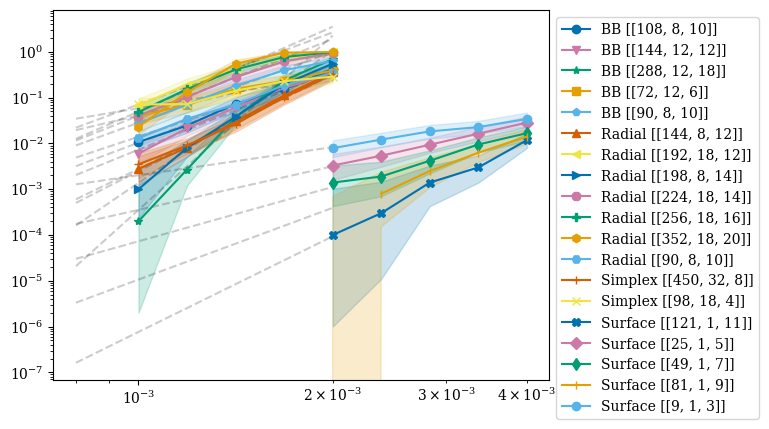

In [28]:
fig,ax = plt.subplots()
xs_test = np.geomspace(8e-4, 2e-3, 10)
for fp in fit_params:
    print(fp)
    plt.plot(xs_test, logical_fit(xs_test, *fp), 'k--', alpha=0.2)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda s: s.json_metadata['p'],
    group_func=lambda s: f"{s.json_metadata['type']} [[{s.json_metadata['n']}, {s.json_metadata['k']}, {s.json_metadata['d']}]]"
)

plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.loglog()
plt.show()

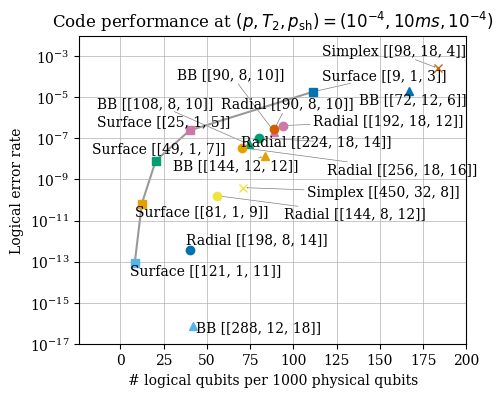

In [18]:
from adjustText import adjust_text

p_tgt = 1e-4
T2_tgt = 10**(-6-np.log10(p_tgt))
p_sh_tgt = p_tgt

markerdict = {
    'Surface':'s',
    'BB':'^',
    'Radial':'o',
    'Simplex':'x',
}

fig,ax = plt.subplots(figsize=(5,4))
points = [(np.nan, np.nan) for _ in code_ids]
texts = []
for i,(code_type, (n,k,d)) in enumerate(code_ids):
    if np.all(np.isfinite(fit_params[i])):
        ler_proj = logical_fit(p_tgt, *fit_params[i])
        enc_rate = k / n
        points[i] = (enc_rate*1000, ler_proj)
        plt.plot(*points[i], marker=markerdict[code_type])
        texts.append(plt.text(*points[i], f'{code_type} [[{n}, {k}, {d}]]', ha='center', va='center'))
xs_surface = []
ys_surface = []
for d in ds_surface:
    pt = points[code_ids.index(('Surface', (d**2,1,d)))]
    xs_surface.append(pt[0])
    ys_surface.append(pt[1])
plt.plot(xs_surface, ys_surface, 'k-', alpha=0.4, zorder=0)
plt.yscale('log')
plt.title(r'Code performance at $(p,T_2,p_\text{sh})=(10^{' + f'{int(np.log10(p_tgt))}' + r'}, '+ f'{T2_tgt*1e3:2g}ms' + r', 10^{' + f'{int(np.log10(p_sh_tgt))}' + r'})$')
plt.xlabel('# logical qubits per 1000 physical qubits')
plt.ylabel('Logical error rate')
plt.xlim(-24, 200)
plt.ylim(1e-17, 1e-2)
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), force_text=(0.5,0.5))
ax.annotate('', xytext=(100, 1e-12), xy=(50, -1e-12), arrowprops=dict(arrowstyle='->', lw=2))
plt.grid(which='both', linewidth=0.5)
plt.savefig('notebooks/fig/10_encoding_rate.pdf', bbox_inches='tight')
plt.savefig('notebooks/fig/10_encoding_rate.svg', bbox_inches='tight')
plt.show()

In [29]:
class ScheduleMetrics:
    qubit_active_durations: dict[int, int]
    qubit_idle_durations: dict[int, int]
    qubit_distance_traveled: dict[int, int]
    avg_qubit_idle_frac: float
    # avg_distance_traveled: float

    def __init__(self, schedule: device.CompiledShuttlingSchedule):
        self.qubit_active_durations = dict()
        qubit_init_times = dict()
        qubit_last_active = dict()
        self.qubit_idle_durations = dict()
        self.qubit_distance_traveled = dict()

        for instr, start_time in zip(schedule.instructions, schedule.instruction_start_times):
            qubits = instr.qubits_list()
            if isinstance(instr, device.Shuttle):
                for q in qubits:
                    self.qubit_distance_traveled[q] = self.qubit_distance_traveled.get(q, 0) + 1
            elif isinstance(instr, device.Instantiate):
                for q in qubits:
                    if q in qubit_init_times:
                        # Starting new round; exit
                        print('Multiple rounds detected; exiting early')
                        return
                    qubit_init_times[q] = start_time
            elif isinstance(instr, device.Measure):
                for q in qubits:
                    self.qubit_active_durations[q] = start_time + instr.duration - qubit_init_times[q]
            for q in qubits:
                if not isinstance(instr, device.Instantiate) and qubit_last_active[q] < start_time:
                    self.qubit_idle_durations[q] = self.qubit_idle_durations.get(q, 0) + start_time - qubit_last_active[q]
                qubit_last_active[q] = start_time + instr.duration
        self.avg_qubit_idle_frac = float(np.mean([d/self.qubit_active_durations[q] for q,d in self.qubit_idle_durations.items() if q in self.qubit_distance_traveled]))
        self.avg_distance_traveled = float(np.mean([d for d in self.qubit_distance_traveled.items()]))

In [31]:
schedules

{('Surface', (9, 1, 3)): <src.device.CompiledShuttlingSchedule at 0x119798c20>,
 ('Surface',
  (25, 1, 5)): <src.device.CompiledShuttlingSchedule at 0x11d2b7680>}

Multiple rounds detected; exiting early
[4, 4, 4, 4, 4, 4, 4, 4]
Multiple rounds detected; exiting early
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


KeyError: ('Surface', (49, 1, 7))

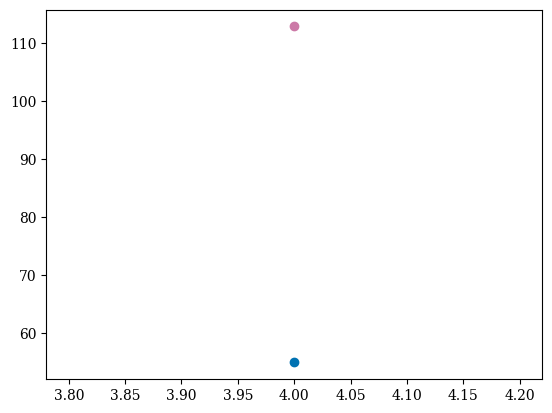

In [30]:
# TODO: look at performance at fixed p vs. average distance shuttled per ancilla
# qubit

p_tgt = 1e-3
T2_tgt = 10**(-6-np.log10(p_tgt))
p_sh_tgt = p_tgt

for i,(code_type, (n,k,d)) in enumerate(code_ids):
    sched = schedules[(code_type, (n,k,d))]
    sched_metrics = ScheduleMetrics(sched)
    print(list(sched_metrics.qubit_distance_traveled.values()))
    fp = fit_params[i]
    if np.all(np.isfinite(fit_params[i])):
        ler_proj = logical_fit(p_tgt, *fit_params[i])
        score = k / n / ler_proj
        plt.plot(np.mean(list(sched_metrics.qubit_distance_traveled.values())), score, 'o')
plt.yscale('log')
plt.show()